<a href="https://colab.research.google.com/github/billalsohail/ML4MC/blob/main/Calum_XGBoost_Workthrough.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

___
## Precursor bash commands

In [1]:
# INSTALL ALL RELEVANT CONDA PACKAGES + DOWNLOAD DATA

! wget https://repo.anaconda.com/miniconda/Miniconda3-py37_4.8.2-Linux-x86_64.sh
! chmod +x Miniconda3-py37_4.8.2-Linux-x86_64.sh
! bash ./Miniconda3-py37_4.8.2-Linux-x86_64.sh -b -f -p /usr/local
import sys
sys.path.append('/usr/local/lib/python3.7/site-packages/')

! conda install -yq -c rdkit rdkit   # need for fingerprints
! conda install -yq -c conda-forge xgboost  # sklearn implementation inefficient
! conda install -yq -c conda-forge tqdm


def download_published_data():
  import io
  from datetime import datetime
  import zipfile

  import requests

  start = datetime.now()
  print(start)
  r = requests.get('https://people.bath.ac.uk/crh53/m1507656.zip')
  zipped = zipfile.ZipFile(io.BytesIO(r.content))
  zipped.extractall('')
  finish = datetime.now()
  print(finish)
  print(finish - start)

download_published_data()
% cd m1507656/

--2021-08-17 10:02:18--  https://repo.anaconda.com/miniconda/Miniconda3-py37_4.8.2-Linux-x86_64.sh
Resolving repo.anaconda.com (repo.anaconda.com)... 104.16.130.3, 104.16.131.3, 2606:4700::6810:8303, ...
Connecting to repo.anaconda.com (repo.anaconda.com)|104.16.130.3|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 85055499 (81M) [application/x-sh]
Saving to: ‘Miniconda3-py37_4.8.2-Linux-x86_64.sh.2’

Miniconda3-py37_4.8 100%[===================>]  81.12M   192MB/s    in 0.4s    

2021-08-17 10:02:18 (192 MB/s) - ‘Miniconda3-py37_4.8.2-Linux-x86_64.sh.2’ saved [85055499/85055499]

PREFIX=/usr/local
Unpacking payload ...
Solving environment: - \ | / - \ | / - \ | / - \ | failed with initial frozen solve. Retrying with flexible solve.
Solving environment: - \ | / - \ | / - \ | / - failed with repodata from current_repodata.json, will retry with next repodata source.
Solving environment: - \ | / - 

___
# Fingerprint Prediction using `XGBoost`

In [2]:
import io

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import pairwise_distances
from sklearn.manifold import TSNE

from rdkit.Chem import MolFromSmiles
from rdkit.Chem import AllChem, DataStructs
from xgboost.sklearn import XGBRegressor

from helpers import get_level

In [3]:
df = pd.read_json('df_62k.json', orient='split')
df.head()

,refcode_csd,canonical_smiles,inchi,number_of_atoms,xyz_pbe_relaxed,energies_occ_pbe,energies_occ_pbe0_vac_tier2,energies_occ_pbe0_water,energies_occ_pbe0_vac_tzvp,energies_occ_pbe0_vac_qzvp,energies_occ_gw_tzvp,energies_occ_gw_qzvp,cbs_occ_gw,energies_unocc_pbe,energies_unocc_pbe0_vac_tier2,energies_unocc_pbe0_water,energies_unocc_pbe0_vac_tzvp,energies_unocc_pbe0_vac_qzvp,energies_unocc_gw_tzvp,energies_unocc_gw_qzvp,cbs_unocc_gw,total_energy_pbe,total_energy_pbe0_vac_tier2,total_energy_pbe0_water,total_energy_pbe0_vac_tzvp,total_energy_pbe0_vac_qzvp,hirshfeld_pbe,hirshfeld_pbe0_vac_tier2,hirshfeld_pbe0_water
0,ABAFEQ,Cc1ccc(cc1)S(=O)(=O)N[C@H](c1nnc(o1)SCc1ccc(cc...,InChI=1S/C18H18ClN3O3S2/c1-12-3-9-16(10-4-12)2...,45,45\n\nO 39.55724515 33.75271314 ...,"[-2759.71553, -2416.30896, -2412.55736, -513.9...","[-2788.05127, -2443.36662, -2439.20276, -526.4...",None,None,None,None,None,None,"[-2.17874, -2.01713, -1.96379, -1.76789, -1.57...","[-1.31866, -1.18964, -1.09242, -0.84089, -0.64...",None,None,None,None,None,None,-63908.261677,-63911.485930,NaN,NaN,NaN,"[-0.27470711000000003, 0.44228032, -0.26425776...","[-0.29802765000000003, 0.47691104, -0.28757556...",None
1,ABEDOC,N#CC(=C(c1ccccc1)c1ccccc1)[C@H](c1ccccc1)NS(=O...,InChI=1S/C28H22N2O2S/c29-21-26(27(22-13-5-1-6-...,55,55\n\nC 8.74281024 13.44863575 ...,"[-2416.32097, -510.97599, -510.93427, -382.106...","[-2443.36734, -523.36541, -523.31866, -392.998...",None,None,None,None,None,None,"[-2.98475, -2.17782, -1.85481, -1.79766, -1.75...","[-2.21768, -1.35105, -0.9864400000000001, -0.9...",None,None,None,None,None,None,-47344.131203,-47346.537633,NaN,NaN,NaN,"[-0.04383635, 0.0489517, -0.04317942, 0.049465...","[-0.04511281, 0.05043578, -0.04467607, 0.05086...",None
2,LODZOT,n1ccc(cc1)c1nnc(o1)c1cccs1\t\n,InChI=1S/C11H7N3OS/c1-2-9(16-7-1)11-14-13-10(1...,23,23\n\nN 23.84904338 42.50577669 ...,"[-2412.75371, -513.88451, -382.11294, -382.041...","[-2439.38001, -526.39732, -393.09445, -393.002...",None,None,None,None,None,None,"[-3.09055, -2.39404, -1.74667, -0.793040000000...","[-2.34328, -1.5493700000000001, -0.80415]",None,None,None,None,None,None,-28915.979909,-28916.826630,NaN,NaN,NaN,"[-0.15366001, 0.01755584, 0.05299325, -0.04774...","[-0.16233532, 0.02121239, 0.05594731, -0.06621...",None
3,LUSREW,CC/C=C(/S(=O)(=O)c1ccc(cc1)C)\F\t\n,"InChI=1S/C11H13FO2S/c1-3-4-11(12)15(13,14)10-7...",28,28\n\nC 36.52340453 39.64067030 ...,"[-2416.01387, -662.1882, -510.96036, -510.9032...","[-2443.06569, -676.06906, -523.38098, -523.310...","[-2443.54535, -676.3259, -523.94531, -523.9294...",None,None,None,None,None,"[-2.3475200000000003, -1.72814, -1.2496, -0.46...","[-1.52729, -0.8295800000000001, -0.29926]","[-1.6158000000000001, -0.82206, -0.38257]",None,None,None,None,None,-29310.525400,-29311.929019,-29312.152528,NaN,NaN,"[-0.10553088000000001, 0.052016810000000004, 0...","[-0.10641357, 0.053639570000000004, 0.05095191...","[-0.10396546, 0.06349725, 0.0567905, 0.0529875..."
4,NOMBEA01,OC(=O)c1cc(N(=O)=O)c(c(c1)N(=O)=O)C\t\n,InChI=1S/C8H6N2O6/c1-4-6(9(13)14)2-5(8(11)12)3...,22,22\n\nC 3.95256786 17.67855833 24.82877401 \nN...,"[-513.17652, -512.6891, -512.67653, -512.67422...","[-525.6547, -525.21649, -525.20741, -525.19172...","[-525.26613, -525.26541, -525.25679, -525.2559...",None,None,None,None,None,"[-4.00974, -3.9692600000000002, -3.28231, -2.1...","[-3.15026, -3.10273, -2.38233, -1.18594, -0.12...","[-3.06, -3.02998, -2.16858, -0.97169]",None,None,None,None,None,-23659.206412,-23657.827976,-23658.213410,NaN,NaN,"[-0.02367444, 0.21031638, -0.16276709, -0.1515...","[-0.01766023, 0.22728532, -0.17862499999999998...","[-0.00545279, 0.23566422, -0.19889062000000002..."


## Feature Generation

In [4]:
prior_len = len(df)

df['rdkit'] = df['canonical_smiles'].apply(MolFromSmiles)
df = df[~df['rdkit'].isna()]  # exclude invalid smiles codes

post_len = len(df)

print(F'{post_len} rdkit molecules generated')
print(F'Rows dropped = {prior_len - post_len}')

61037 rdkit molecules generated
Rows dropped = 452


In [5]:
def mol_to_ecfp(mol, r=3, b=1024):
    """Generate ecfp for passed rdkit mol
    mol : rdkit.chem.Mol
    r : int (radius of ECFP)
      for convention, ECFP<D> --> ECFP<2R> hence radius is passed.
    b : int
      Number of bits to use
    """
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, r, nBits=b)
    array = np.zeros((0,), dtype=np.int8)
    DataStructs.ConvertToNumpyArray(fp, array)
    return array

df['fingerprint'] = df['rdkit'].apply(mol_to_ecfp)

In [6]:
df['fingerprint'].isna().sum()

0

In [19]:
X = np.vstack(df['fingerprint'].values)
y = df.apply(lambda row: get_level(row, level_type='HOMO', subset='PBE+vdW_vacuum'), axis=1).values

print(np.isnan(y).sum())

0


## EDA 
* Split data prior to EDA to prevent bias

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=20210817)

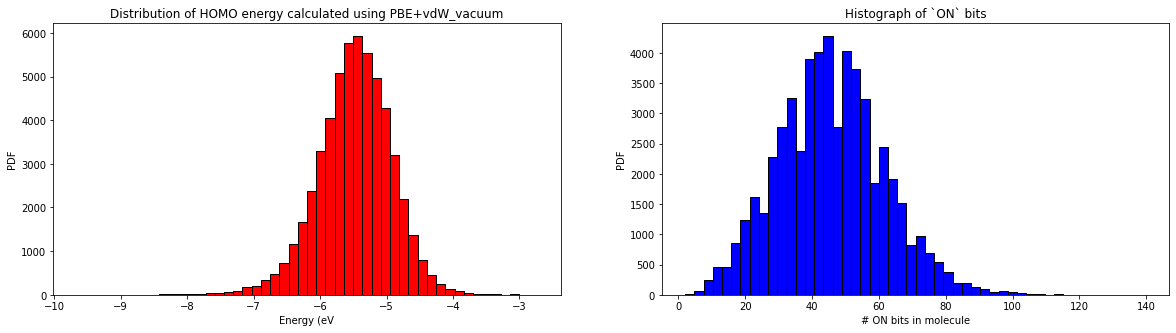

In [21]:
plt.figure(figsize=(20, 5))

plt.subplot(1, 2, 1)
plt.hist(y_train, bins=50, color='r', edgecolor='k')
plt.title(F'Distribution of HOMO energy calculated using PBE+vdW_vacuum')
plt.xlabel('Energy (eV')
plt.ylabel('PDF')

plt.subplot(1, 2, 2)
plt.hist(X_train.sum(1), bins=50, color='b', edgecolor='k')
plt.title('Histograph of `ON` bits')
plt.xlabel('# ON bits in molecule')
plt.ylabel('PDF')

plt.show()

* Target is largely normally distributed
* Feature data is mostly sparse with an average of 40 bits in 1024 (96% Sparse data)

In [22]:
sub_sample = np.random.choice(len(X_train), 5000, replace=False)
X_train_sample, y_train_sample = X_train[sub_sample], y_train[sub_sample]

similarities = 1 - pairwise_distances(X_train_sample, X_train_sample, metric='jaccard', n_jobs=-1)

/usr/local/lib/python3.7/dist-packages/sklearn/metrics/pairwise.py:1738: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


In [23]:
similarities.shape

(5000, 5000)

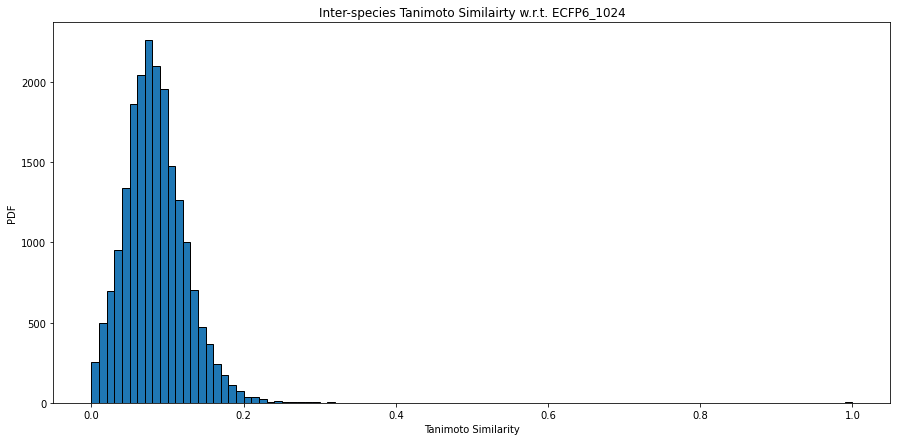

In [24]:
sample = np.random.choice(similarities.ravel(), 20000, replace=False)

plt.figure(figsize=(15, 7))
plt.hist(sample, bins=100, edgecolor="black")
plt.title('Inter-species Tanimoto Similairty w.r.t. ECFP6_1024')
plt.xlabel('Tanimoto Similarity')
plt.ylabel('PDF')
plt.show()

* From low similarity distribution it seems that molecules are diverse w.r.t. themselves

### Visualisation of fingerprints and target values using `t-SNE` 
* Ideally would use `UMAP` but issues installing on collab
* Will try `t-SNE` since this allows for `jaccard` distance metric to be used

In [32]:
reducer = TSNE(metric='jaccard', n_components=2)  # 2 output columns
embedding = reducer.fit_transform(X_train_sample)

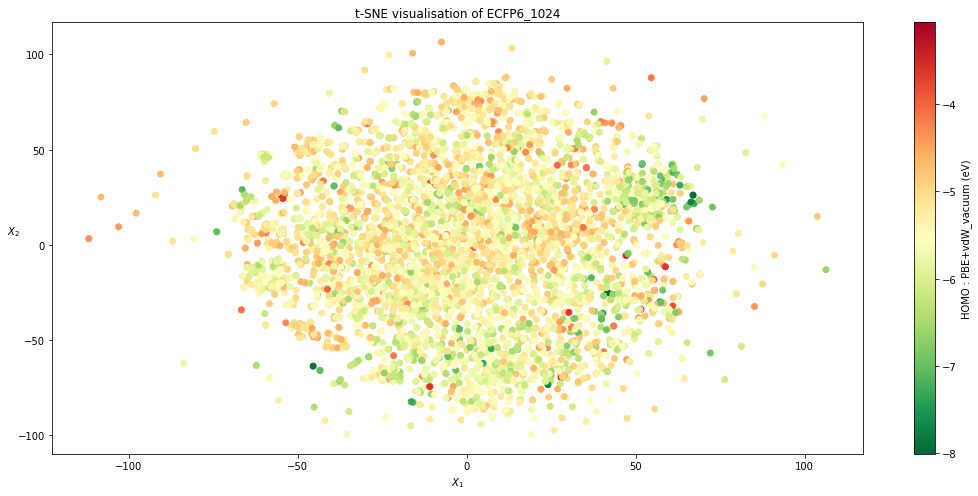

In [35]:
plt.figure(figsize=(15, 7))
plt.title('t-SNE visualisation of ECFP6_1024')
p = plt.scatter(embedding[:, 0], embedding[:, 1], c=y_train_sample, cmap='RdYlGn_r')
cbar = plt.colorbar(p)
cbar.set_label('HOMO : PBE+vdW_vacuum (eV)')
plt.xlabel('$X_1$')
plt.ylabel('$X_2$', rotation=0)
plt.tight_layout()
plt.show()

* No immediately clear data clumps w.r.t. HOMO level and t-SNE representation

___
## Baseline `XGBoost` Performance
* Observe model performance with no hyperparameter tuning
* Also compare against a mean prediction model

In [45]:
from sklearn.metrics import mean_absolute_error
from sklearn.dummy import DummyRegressor

In [36]:
model = XGBRegressor(objective='reg:squarederror')

In [37]:
X_tr, X_cv, y_tr, y_cv = train_test_split(X_train, y_train, test_size=0.2)

In [38]:
model.fit(X_tr, y_tr)

XGBRegressor(base_score=0.5, booster='gbtree', colsample_bylevel=1,
             colsample_bynode=1, colsample_bytree=1, gamma=0,
             importance_type='gain', learning_rate=0.1, max_delta_step=0,
             max_depth=3, min_child_weight=1, missing=None, n_estimators=100,
             n_jobs=1, nthread=None, objective='reg:squarederror',
             random_state=0, reg_alpha=0, reg_lambda=1, scale_pos_weight=1,
             seed=None, silent=None, subsample=1, verbosity=1)

In [64]:
y_pred_cv = model.predict(X_cv)
xgb_error_cv = mean_absolute_error(y_cv, y_pred_cv)
xgb_error_tr = mean_absolute_error(y_tr, model.predict(X_tr))

In [66]:
print(F'TR : Baseline XGBoost MAE = {xgb_error_tr:.3f} eV')
print(F'CV : Baseline XGBoost MAE = {xgb_error_cv:.3f} eV')

TR : Baseline XGBoost MAE = 0.304 eV
CV : Baseline XGBoost MAE = 0.309 eV


In [67]:
dummy = DummyRegressor(strategy='mean')
dummy.fit(X_tr, y_tr)
y_pred_cv_dum = dummy.predict(X_cv)
dummy_error_cv = mean_absolute_error(y_cv, y_pred_cv_dum)
dummy_error_tr = mean_absolute_error(y_tr, dummy.predict(X_tr))

print(F'TR : Mean prediction MAE = {dummy_error_tr:.3f} eV')
print(F'CV : Mean prediction MAE = {dummy_error_cv:.3f} eV')

TR : Mean prediction MAE = 0.429 eV
CV : Mean prediction MAE = 0.428 eV


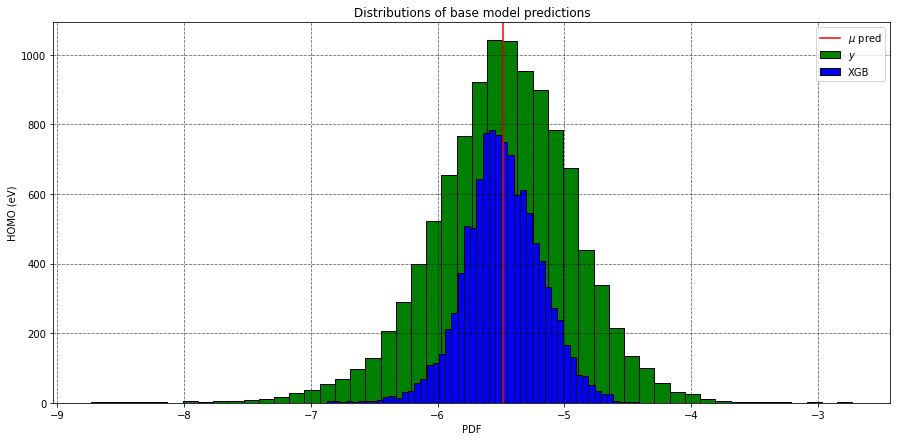

In [63]:
plt.figure(figsize=(15,7))
plt.title('Distributions of base model predictions')
plt.hist(y_cv, bins=50, color='g', edgecolor='k', label='$y$')
plt.hist(y_pred_cv, bins=50, color='b', edgecolor='k', label='XGB')
plt.axvline(y_pred_cv_dum[0], color='r', label='$\mu$ pred')

plt.xlabel('PDF')
plt.ylabel('HOMO (eV)')

plt.legend()
plt.grid(linestyle='--', alpha=0.6, color='k')

plt.show()

* Baseline model demonstrates that the features + model have some predictive capability due to the lower `MAE` than the mean prediction model
* Curious about the size of data required for training of models
* Also curious about any overfitting occuring

In [ ]:
# max depth : [1, 2, 3, 4, 5]
# Data Size : [10, 100, 1000, 10000] 

## Varying data size

In [112]:
data_scores = {'train': [], 'test': []}

data_sizes = [10, 100, 1000, 10000, 20000, 40000]
potential_indices = np.arange(len(X_train))

for d in tqdm(data_sizes):
  for _ in range(4):

    tr_sample = np.random.choice(potential_indices, size=d, replace=False)
    cv_sample = np.delete(potential_indices, tr_sample)

    X_tr, y_tr = X_train[tr_sample], y_train[tr_sample]
    X_cv, y_cv = X_train[cv_sample], y_train[cv_sample]

    model = XGBRegressor(objective='reg:squarederror')

    model.fit(X_tr, y_tr)
    tr_score = mean_absolute_error(y_tr, model.predict(X_tr))
    cv_score = mean_absolute_error(y_cv, model.predict(X_cv))

    data_scores['train'].append(tr_score)
    data_scores['test'].append(cv_score)

100%|██████████| 6/6 [09:55<00:00, 99.29s/it] 


In [113]:
repeated_sizes = sorted(data_sizes * 4)  # cheating because can just sort the values here rather than iterating
repeated_sizes_log = np.log10(repeated_sizes)  # cheating because can just sort the values here rather than iterating

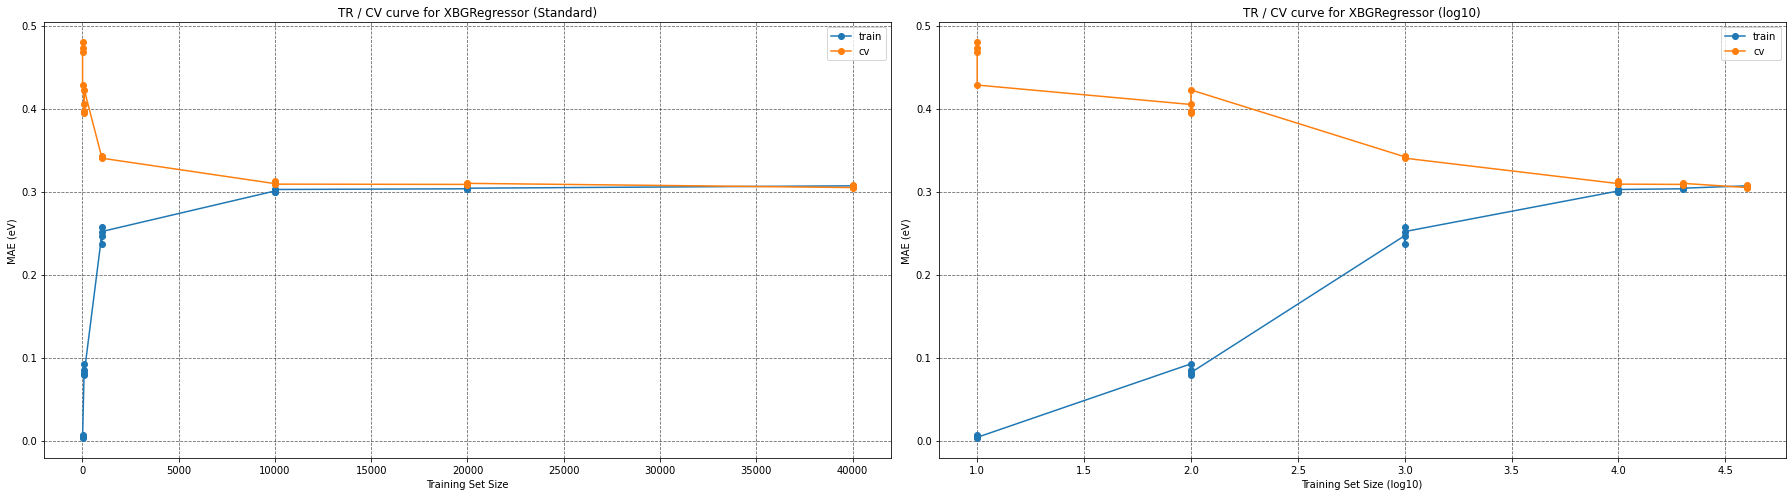

In [114]:
plt.figure(figsize=(25, 7))

plt.subplot(1, 2, 1)
plt.title('TR / CV curve for XBGRegressor (Standard)')
plt.plot(repeated_sizes, data_scores['train'], '-o', label='train')
plt.plot(repeated_sizes, data_scores['test'], '-o', label='cv')
plt.xlabel('Training Set Size')
plt.ylabel('MAE (eV)')
plt.grid(alpha=0.6, color='k', linestyle='--')
plt.legend()

plt.subplot(1, 2, 2)
plt.title('TR / CV curve for XBGRegressor (log10)')
plt.plot(repeated_sizes_log, data_scores['train'], '-o', label='train')
plt.plot(repeated_sizes_log, data_scores['test'], '-o', label='cv')
plt.xlabel('Training Set Size (log10)')
plt.ylabel('MAE (eV)')
plt.grid(alpha=0.6, color='k', linestyle='--')
plt.legend()

plt.tight_layout()
plt.show()

* Can see the `train` and `cv` scores start to plataeu at higher and higher volumes of training data
* This is indicative of a model suffering from `bias`
* Would therefore indicate that either:
> 1. The `ECFP6_1024` fingerprints do not adequately map the compounds to the target values
> 2. The `XGBoost` model does not model the relationship sufficiently

## Varying `Max_depth` hyperparameter

In [75]:
scores = {'train': [], 'test': []}

depths = list(range(1, 6))

for d in tqdm(depths):
  X_tr, X_cv, y_tr, y_cv = train_test_split(X_train, y_train, test_size=0.2)

  model = XGBRegressor(objective='reg:squarederror', max_depth=d)
  model.fit(X_tr, y_tr)
  tr_score = mean_absolute_error(y_tr, model.predict(X_tr))
  cv_score = mean_absolute_error(y_cv, model.predict(X_cv))

  scores['train'].append(tr_score)
  scores['test'].append(cv_score)

100%|██████████| 5/5 [07:30<00:00, 90.12s/it] 


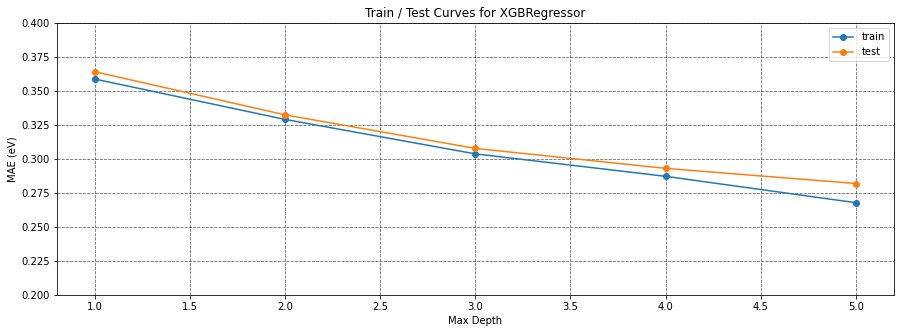

In [84]:
plt.figure(figsize=(15, 5))
plt.title('Train / Test Curves for XGBRegressor')
plt.plot(depths, scores['train'], '-o', label='train')
plt.plot(depths, scores['test'], '-o', label='test')
plt.xlabel('Max Depth')
plt.ylabel('MAE (eV)')
plt.grid(alpha=0.6, color='k', linestyle='--')
plt.legend()
plt.ylim(0.2, 0.4)
plt.show()

* given the close overlap of training and testing scores doesn't seem that there is much point varying this value

___
## Conclusions
>* Generated `ECFP6_1024` fingerprints for 61,000 molecules
>* Used these to try and predict the `HOMO` energy levels for these molecules using the `PBE+vdW_vacuum` level of theory
>* While initial prediction results were promising (i.e. some relationship was observed which allowed a better than "crude" approach) overall the XGBoost regressor was found to suffer from bias
>* Solving this bias could be likely be achieved by the use of more electrostatic based descriptors
___